# **EDA: Vídeos varios (YouTube)**

- **Fuente:** Elaboración propia (Andrés)
- **Dataset unificado:** 6,974 muestras · 5 clases · 6 features acústicas comunes
- **Clases:** fire · gunshot · car_crash · explosion · crying

Este dataset contiene **6.974 segmentos de audio de 5 segundos** extraídos de vídeos de YouTube. El procesamiento consistió en descargar los primeros 30 minutos de cada vídeo con yt-dlp, segmentar el audio en clips de 5 segundos con librosa y filtrar por energía mínima para eliminar silencios. De cada segmento se extrajeron 6 features acústicas (peak, rms, centroid, zcr, kurtosis, attack_ratio). Se está utilizando para reforzar las 5 clases del modelo (`fire`, `gunshot`, `explosion`, `car_crash` y `crying`) con audio procedente de contextos reales y variados.

## **1. Importaciones y configuración**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
from scipy.stats import kurtosis as scipy_kurtosis
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas.')

Librerías cargadas.


In [2]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'fire': 'steelblue',
    'gunshot': 'crimson',
    'car_crash': 'salmon',
    'explosion': 'green',
    'crying': 'purple',
}
CLASSES = list(COLORS.keys())
FEATURES = ['peak', 'rms', 'centroid', 'zcr', 'kurtosis', 'attack_ratio']

## **2. Carga y estructura del dataset**

In [3]:
df = pd.read_csv("/content/unified_dataset.csv")

In [4]:
print(f"Shape: {df.shape[0]} filas × {df.shape[1]} columnas")

Shape: 6974 filas × 13 columnas


In [5]:
df.head(10)

,file,class,label_positive,duration,peak,rms,centroid,zcr,kurtosis,attack_ratio,rolloff,flatness,crest_factor
0,/home/andres/Documentos/proyecto4geeks/data/ra...,fire,True,5.0,0.854544,0.050271,703.690390,0.006854,3.094676,0.848040,NaN,NaN,NaN
1,/home/andres/Documentos/proyecto4geeks/data/ra...,fire,True,5.0,0.373646,0.014043,1866.962719,0.038642,20.859148,1.236833,NaN,NaN,NaN
2,/home/andres/Documentos/proyecto4geeks/data/ra...,fire,True,5.0,0.505450,0.011054,2440.815679,0.131244,249.578827,1.061009,NaN,NaN,NaN
3,/home/andres/Documentos/proyecto4geeks/data/ra...,fire,True,5.0,0.273339,0.057912,561.600143,0.006422,-0.216013,0.812228,NaN,NaN,NaN
4,/home/andres/Documentos/proyecto4geeks/data/ra...,fire,True,5.0,0.971907,0.050475,649.070384,0.009300,17.995201,1.003024,NaN,NaN,NaN
5,/home/andres/Documentos/proyecto4geeks/data/ra...,fire,True,5.0,0.829352,0.040570,1613.198261,0.035310,13.188547,1.161471,NaN,NaN,NaN
6,/home/andres/Documentos/proyecto4geeks/data/ra...,fire,True,5.0,0.624464,0.011989,2189.348244,0.050065,143.186798,1.156387,NaN,NaN,NaN
7,/home/andres/Documentos/proyecto4geeks/data/ra...,fire,True,5.0,0.210260,0.014602,1838.628393,0.029014,3.367671,1.317023,NaN,NaN,NaN
8,/home/andres/Documentos/proyecto4geeks/data/ra...,fire,True,5.0,0.216908,0.016252,2258.439985,0.119301,5.133763,0.925292,NaN,NaN,NaN
9,/home/andres/Documentos/proyecto4geeks/data/ra...,fire,True,5.0,0.624165,0.038412,1348.814753,0.023908,1.762857,0.913547,NaN,NaN,NaN


In [6]:
df.tail(10)

,file,class,label_positive,duration,peak,rms,centroid,zcr,kurtosis,attack_ratio,rolloff,flatness,crest_factor
6964,crying_processed\WxsnLwrG_8A_seg10.wav,crying,True,5.0,1.000000,0.312771,1787.747750,0.035523,0.039919,0.874914,NaN,NaN,NaN
6965,crying_processed\WxsnLwrG_8A_seg11.wav,crying,True,5.0,0.995728,0.264574,1734.716295,0.032570,0.592120,1.788067,NaN,NaN,NaN
6966,crying_processed\WxsnLwrG_8A_seg2.wav,crying,True,5.0,1.000000,0.323021,2111.970471,0.045449,-0.309057,1.137165,NaN,NaN,NaN
6967,crying_processed\WxsnLwrG_8A_seg3.wav,crying,True,5.0,0.999969,0.307115,2216.279889,0.048225,-0.259406,1.088985,NaN,NaN,NaN
6968,crying_processed\WxsnLwrG_8A_seg4.wav,crying,True,5.0,0.991119,0.299108,1766.995854,0.037321,0.028006,1.401075,NaN,NaN,NaN
6969,crying_processed\WxsnLwrG_8A_seg5.wav,crying,True,5.0,1.000000,0.347397,1760.316622,0.043024,0.015965,0.773107,NaN,NaN,NaN
6970,crying_processed\WxsnLwrG_8A_seg6.wav,crying,True,5.0,0.998138,0.278379,1716.538375,0.038247,0.203625,1.409737,NaN,NaN,NaN
6971,crying_processed\WxsnLwrG_8A_seg7.wav,crying,True,5.0,0.965454,0.293412,1209.432240,0.026469,-0.098768,0.954656,NaN,NaN,NaN
6972,crying_processed\WxsnLwrG_8A_seg8.wav,crying,True,5.0,1.000000,0.347643,1718.682788,0.043227,-0.282698,1.256325,NaN,NaN,NaN
6973,crying_processed\WxsnLwrG_8A_seg9.wav,crying,True,5.0,0.999969,0.327221,1682.253382,0.047202,-0.179091,0.997017,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6974 entries, 0 to 6973
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   file            6974 non-null   object 
 1   class           6974 non-null   object 
 2   label_positive  6974 non-null   bool   
 3   duration        6974 non-null   float64
 4   peak            6974 non-null   float64
 5   rms             6974 non-null   float64
 6   centroid        6974 non-null   float64
 7   zcr             6974 non-null   float64
 8   kurtosis        6974 non-null   float64
 9   attack_ratio    6974 non-null   float64
 10  rolloff         980 non-null    float64
 11  flatness        980 non-null    float64
 12  crest_factor    980 non-null    float64
dtypes: bool(1), float64(10), object(2)
memory usage: 660.8+ KB


In [8]:
print("Estadísticas descriptivas")
df[FEATURES].describe().round(4)

Estadísticas descriptivas


,peak,rms,centroid,zcr,kurtosis,attack_ratio
count,6974.0000,6974.0000,6974.0000,6974.0000,6974.0000,6974.0000
mean,0.6164,0.0955,1837.4822,0.0594,25.3625,1.1381
std,0.2758,0.0925,980.7415,0.0412,62.3069,2.0589
min,0.0990,0.0071,87.5485,0.0024,-1.6924,0.0000
25%,0.4113,0.0356,1099.1057,0.0306,1.2967,0.6689
50%,0.5982,0.0600,1613.3786,0.0481,4.9619,0.9758
75%,0.8153,0.1195,2386.3292,0.0718,17.2871,1.2007
max,1.2926,0.7447,4830.4739,0.2917,611.9180,113.0154


In [9]:
df.columns

Index(['file', 'class', 'label_positive', 'duration', 'peak', 'rms',
       'centroid', 'zcr', 'kurtosis', 'attack_ratio', 'rolloff', 'flatness',
       'crest_factor'],
      dtype='object')

In [10]:
# Valores nulos
print("Valores nulos")
df.isnull().sum()

Valores nulos


,0
file,0
class,0
label_positive,0
duration,0
peak,0
rms,0
centroid,0
zcr,0
kurtosis,0
attack_ratio,0


In [11]:
print("Valores faltantes del dataframe")
df.isna().sum().sum()

Valores faltantes del dataframe


np.int64(17982)

In [12]:
print("Valores faltantes para cada columna")
df.isna().sum()

Valores faltantes para cada columna


,0
file,0
class,0
label_positive,0
duration,0
peak,0
rms,0
centroid,0
zcr,0
kurtosis,0
attack_ratio,0


In [13]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

,0
flatness,85.947806
crest_factor,85.947806
rolloff,85.947806
class,0.000000
file,0.000000
peak,0.000000
duration,0.000000
label_positive,0.000000
rms,0.000000
kurtosis,0.000000


In [14]:
print("Tipos de datos")
df.dtypes

Tipos de datos


,0
file,object
class,object
label_positive,bool
duration,float64
peak,float64
rms,float64
centroid,float64
zcr,float64
kurtosis,float64
attack_ratio,float64


In [15]:
print("Posibles variables categóricas")
df.select_dtypes(include=['object']).columns

Posibles variables categóricas


Index(['file', 'class'], dtype='object')

## **3. Balance de clases**

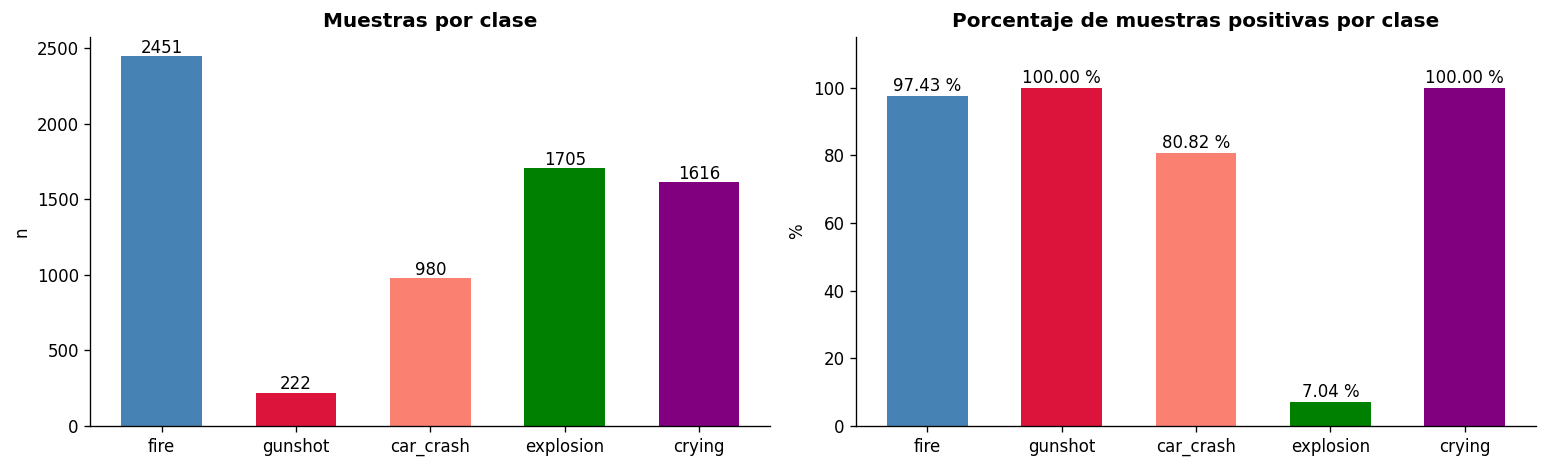

Desbalanceo severo: gunshot (222) vs. fire (2.451) = ratio 1:11
Explosion solo tiene 7 % de positivos. Es una etiqueta muy restrictiva


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Conteo por clase
counts = df['class'].value_counts().reindex(CLASSES)
axes[0].bar(CLASSES, counts.values, color=[COLORS[c] for c in CLASSES], width=0.6)
axes[0].set_title('Muestras por clase', fontweight='bold')
axes[0].set_ylabel('n')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Porcentaje de positivos por clase
pct = {cls: df[df['class']==cls]['label_positive'].mean()*100 for cls in CLASSES}
axes[1].bar(CLASSES, [pct[c] for c in CLASSES], color=[COLORS[c] for c in CLASSES], width=0.6)
axes[1].set_title('Porcentaje de muestras positivas por clase', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 115)
for i, cls in enumerate(CLASSES):
    axes[1].text(i, pct[cls] + 1.5, f"{pct[cls]:.2f} %", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Desbalanceo severo: gunshot (222) vs. fire (2.451) = ratio 1:11")
print("Explosion solo tiene 7 % de positivos. Es una etiqueta muy restrictiva")

## **4. Distribuciones por feature**

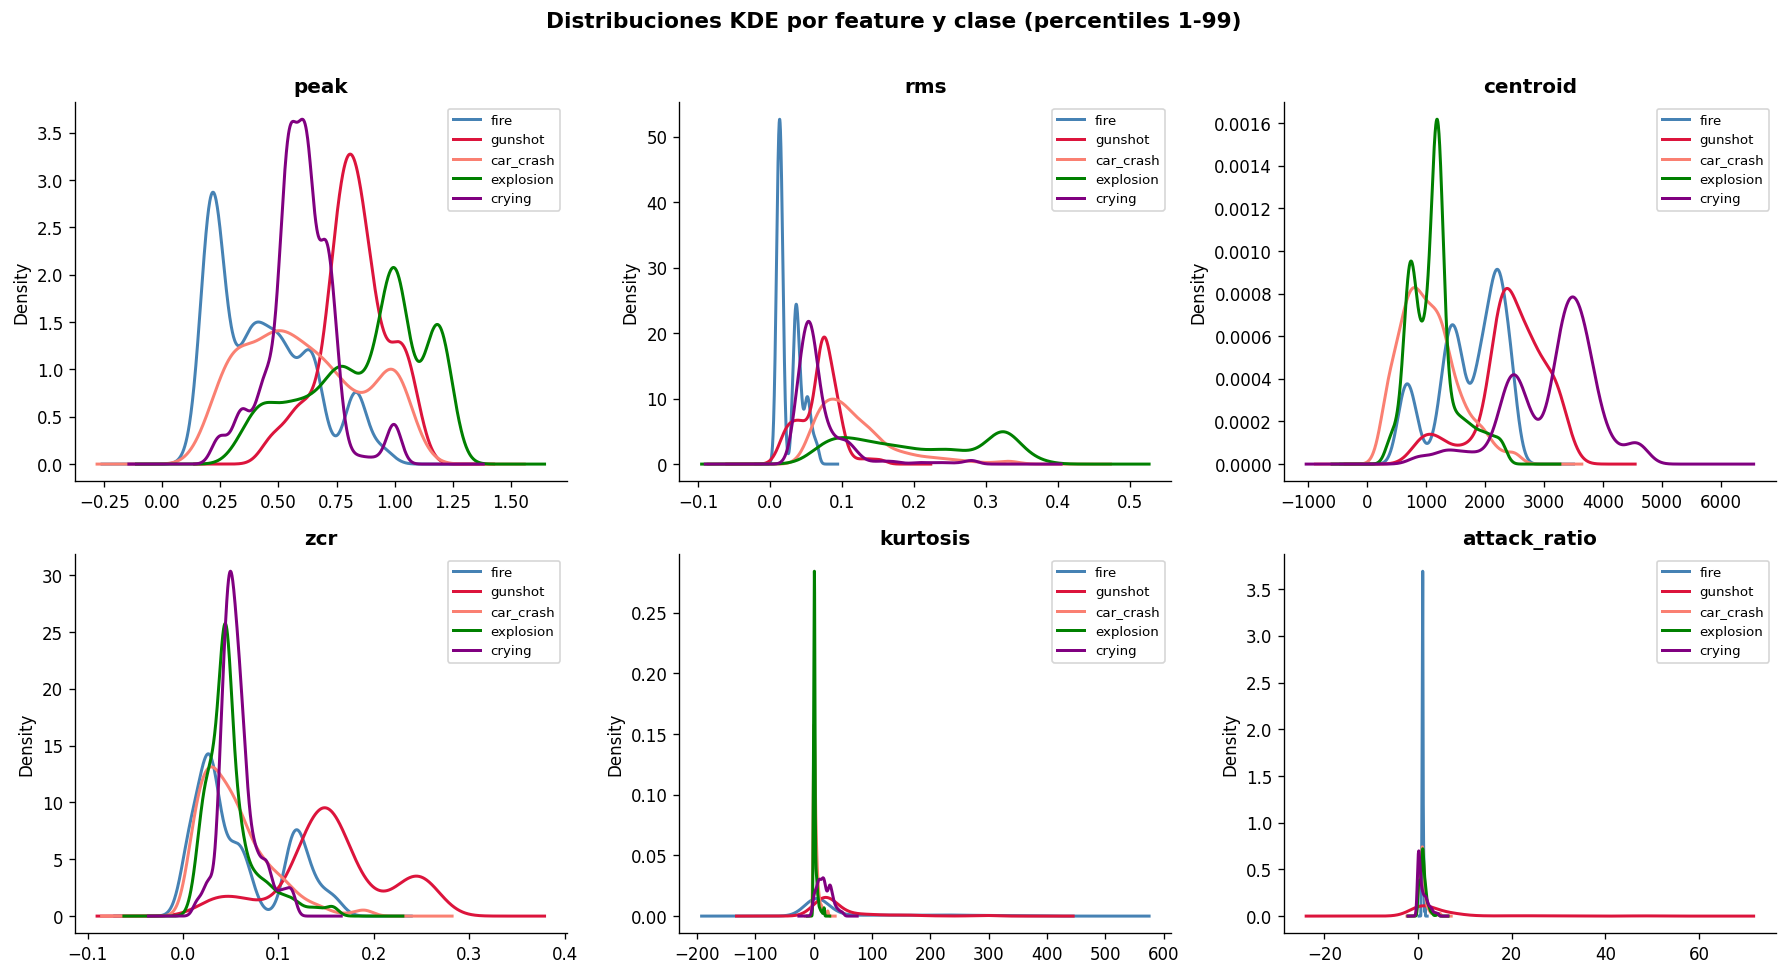

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feat in enumerate(FEATURES):
    ax = axes[idx]
    for cls in CLASSES:
        vals = df[df['class']==cls][feat].dropna()
        # Limitar outliers extremos para visualización
        p1, p99 = vals.quantile(0.01), vals.quantile(0.99)
        vals_clipped = vals.clip(p1, p99)
        vals_clipped.plot.kde(ax=ax, color=COLORS[cls], linewidth=1.8, label=cls)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones KDE por feature y clase (percentiles 1-99)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## **5. Boxplots por clase**

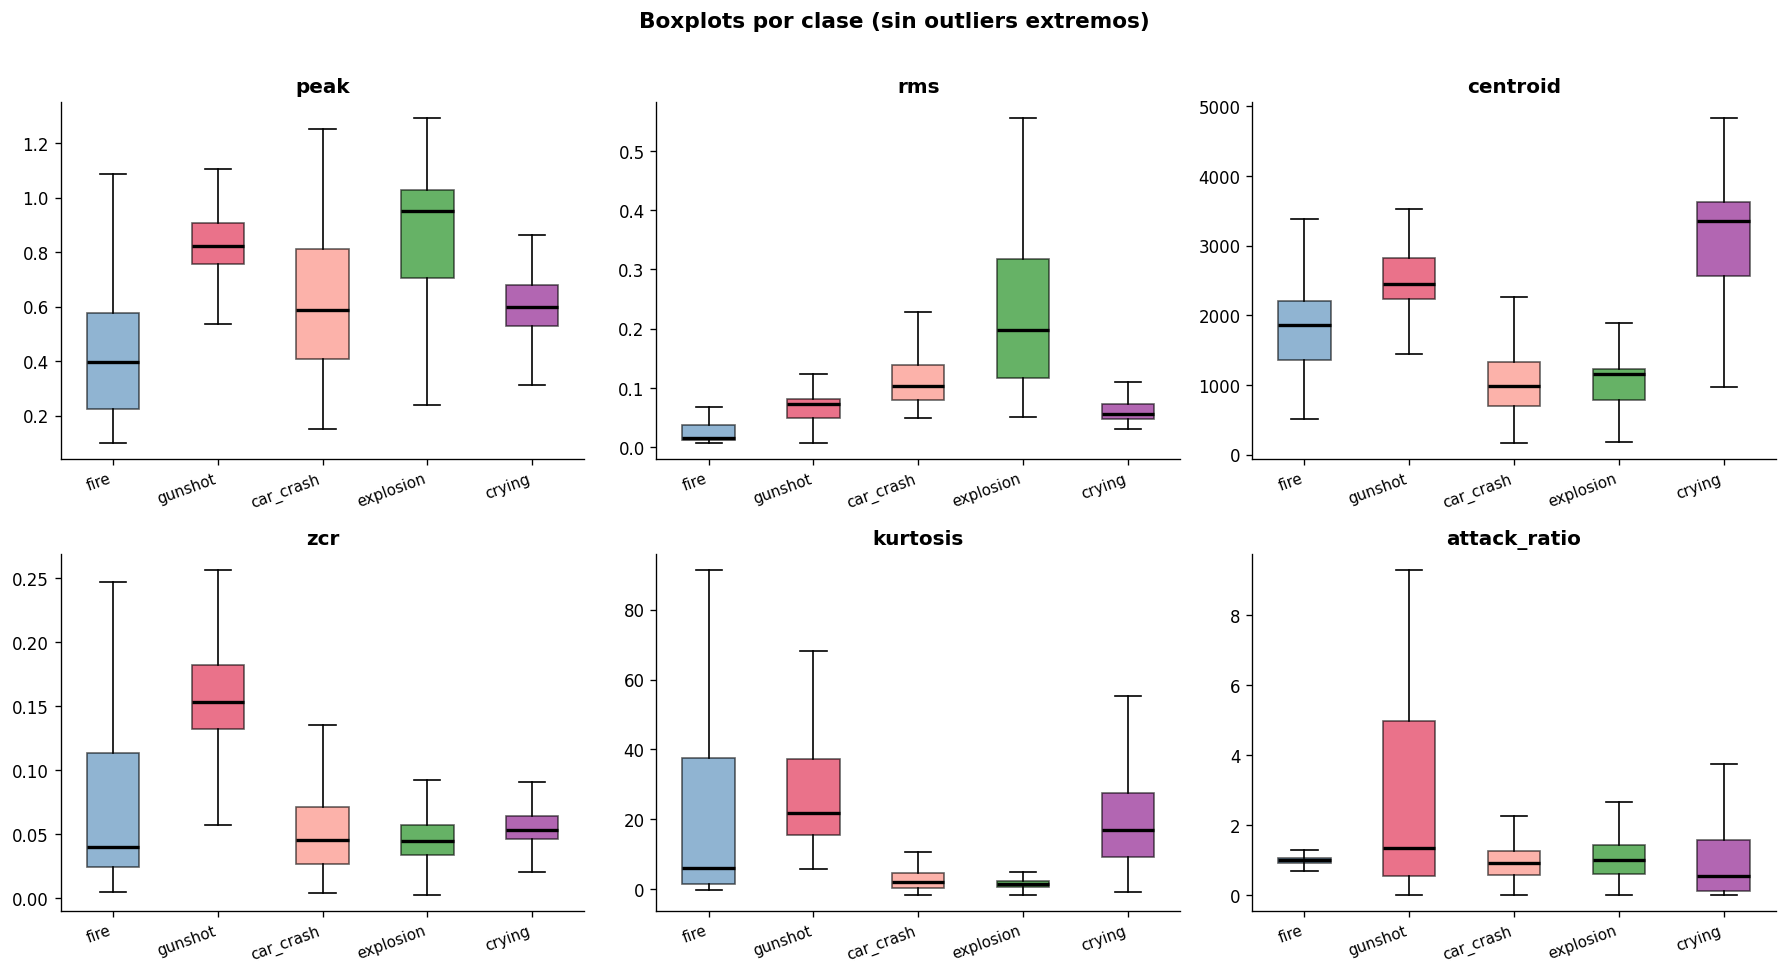

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feat in enumerate(FEATURES):
    ax = axes[idx]
    data = [df[df['class']==cls][feat].dropna().values for cls in CLASSES]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, cls in zip(bp['boxes'], CLASSES):
        patch.set_facecolor(COLORS[cls])
        patch.set_alpha(0.6)
    ax.set_xticks(range(1, len(CLASSES)+1))
    ax.set_xticklabels(CLASSES, rotation=20, ha='right', fontsize=9)
    ax.set_title(feat, fontweight='bold')

plt.suptitle('Boxplots por clase (sin outliers extremos)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## **6. Perfil medio por clase (radar)**

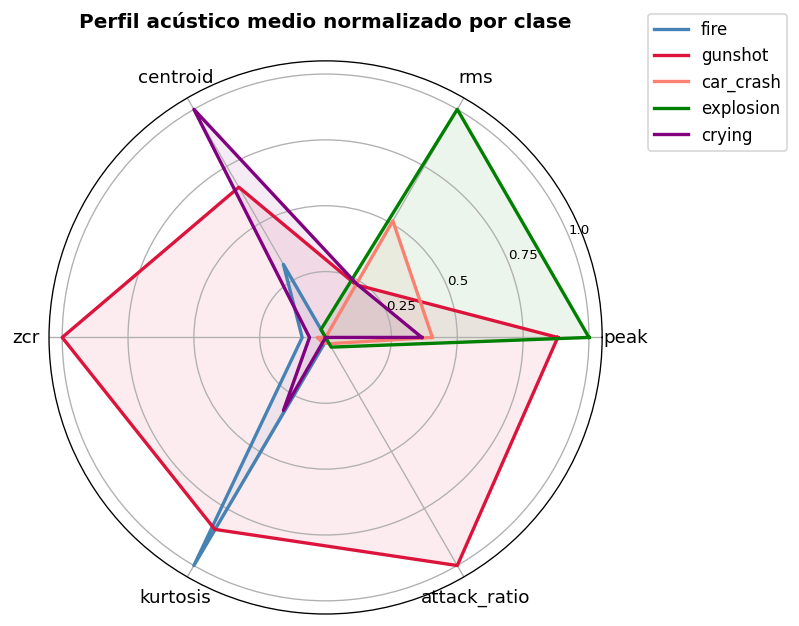

In [19]:
# Normalizar medias al rango [0,1] por feature
means_raw = {cls: [df[df['class']==cls][f].mean() for f in FEATURES] for cls in CLASSES}
mins = np.array([min(means_raw[c][i] for c in CLASSES) for i in range(len(FEATURES))])
maxs = np.array([max(means_raw[c][i] for c in CLASSES) for i in range(len(FEATURES))])
means_norm = {cls: (np.array(means_raw[cls]) - mins) / (maxs - mins + 1e-10) for cls in CLASSES}

N = len(FEATURES)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for cls in CLASSES:
    vals = list(means_norm[cls]) + [means_norm[cls][0]]
    ax.plot(angles, vals, color=COLORS[cls], linewidth=2, label=cls)
    ax.fill(angles, vals, color=COLORS[cls], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(FEATURES, fontsize=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25','0.5','0.75','1.0'], fontsize=8)
ax.set_title('Perfil acústico medio normalizado por clase',
             fontweight='bold', pad=20, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

## **7. Matriz de correlación**

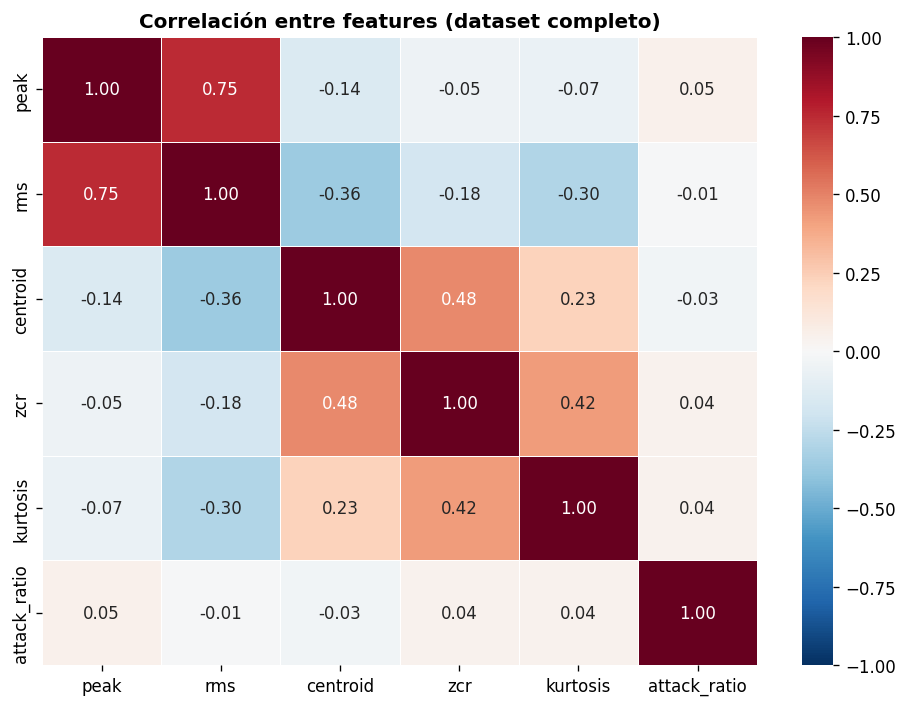

In [20]:
corr = df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr, dtype=bool)
np.fill_diagonal(mask, True)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size': 10})
ax.set_title('Correlación entre features (dataset completo)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
print("Correlaciones más altas:")
corr_vals = corr.abs().unstack().sort_values(ascending=False)
corr_vals = corr_vals[corr_vals < 1.0].drop_duplicates()
print(corr_vals.head(6).to_string())

Correlaciones más altas:
peak      rms         0.748590
zcr       centroid    0.479189
kurtosis  zcr         0.424602
rms       centroid    0.363644
          kurtosis    0.304298
kurtosis  centroid    0.229002


## **8. Detección de outliers (método IQR)**

In [22]:
outlier_counts = {}
for cls in CLASSES:
    sub = df[df['class']==cls]
    outlier_counts[cls] = {}
    for feat in FEATURES:
        vals = sub[feat].dropna()
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        iqr = q3 - q1
        n_out = int(((vals < q1 - 1.5*iqr) | (vals > q3 + 1.5*iqr)).sum())
        outlier_counts[cls][feat] = n_out

df_out = pd.DataFrame(outlier_counts).T
print("Outliers por clase y feature (IQR 1.5×):")
display(df_out)

Outliers por clase y feature (IQR 1.5×):


,peak,rms,centroid,zcr,kurtosis,attack_ratio
fire,1,2,0,0,511,156
gunshot,9,6,20,24,35,16
car_crash,0,55,18,31,68,72
explosion,1,1,110,148,220,62
crying,106,135,19,127,3,34


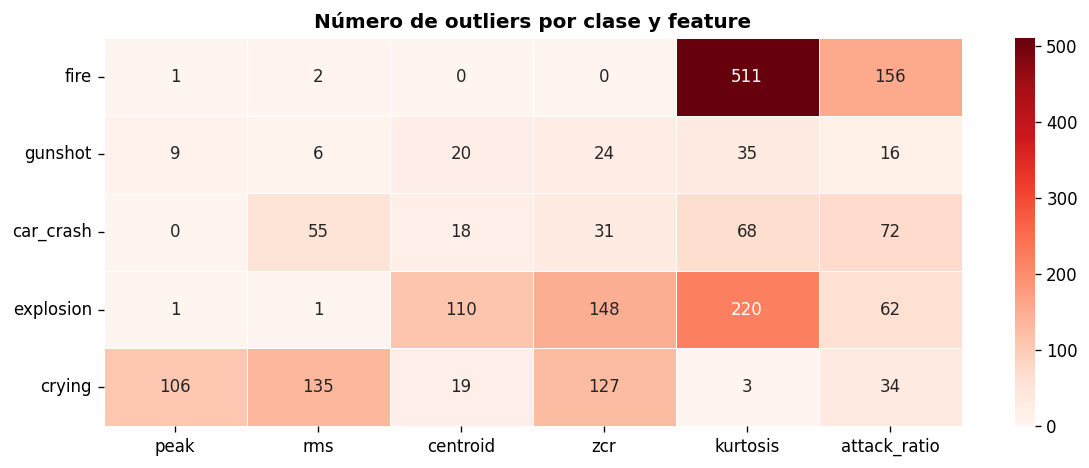

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_out, annot=True, fmt='d', cmap='Reds', ax=ax, linewidths=0.5)
ax.set_title('Número de outliers por clase y feature', fontweight='bold')
plt.tight_layout()
plt.show()

## **9. Separabilidad entre clases (pairplot de features clave)**

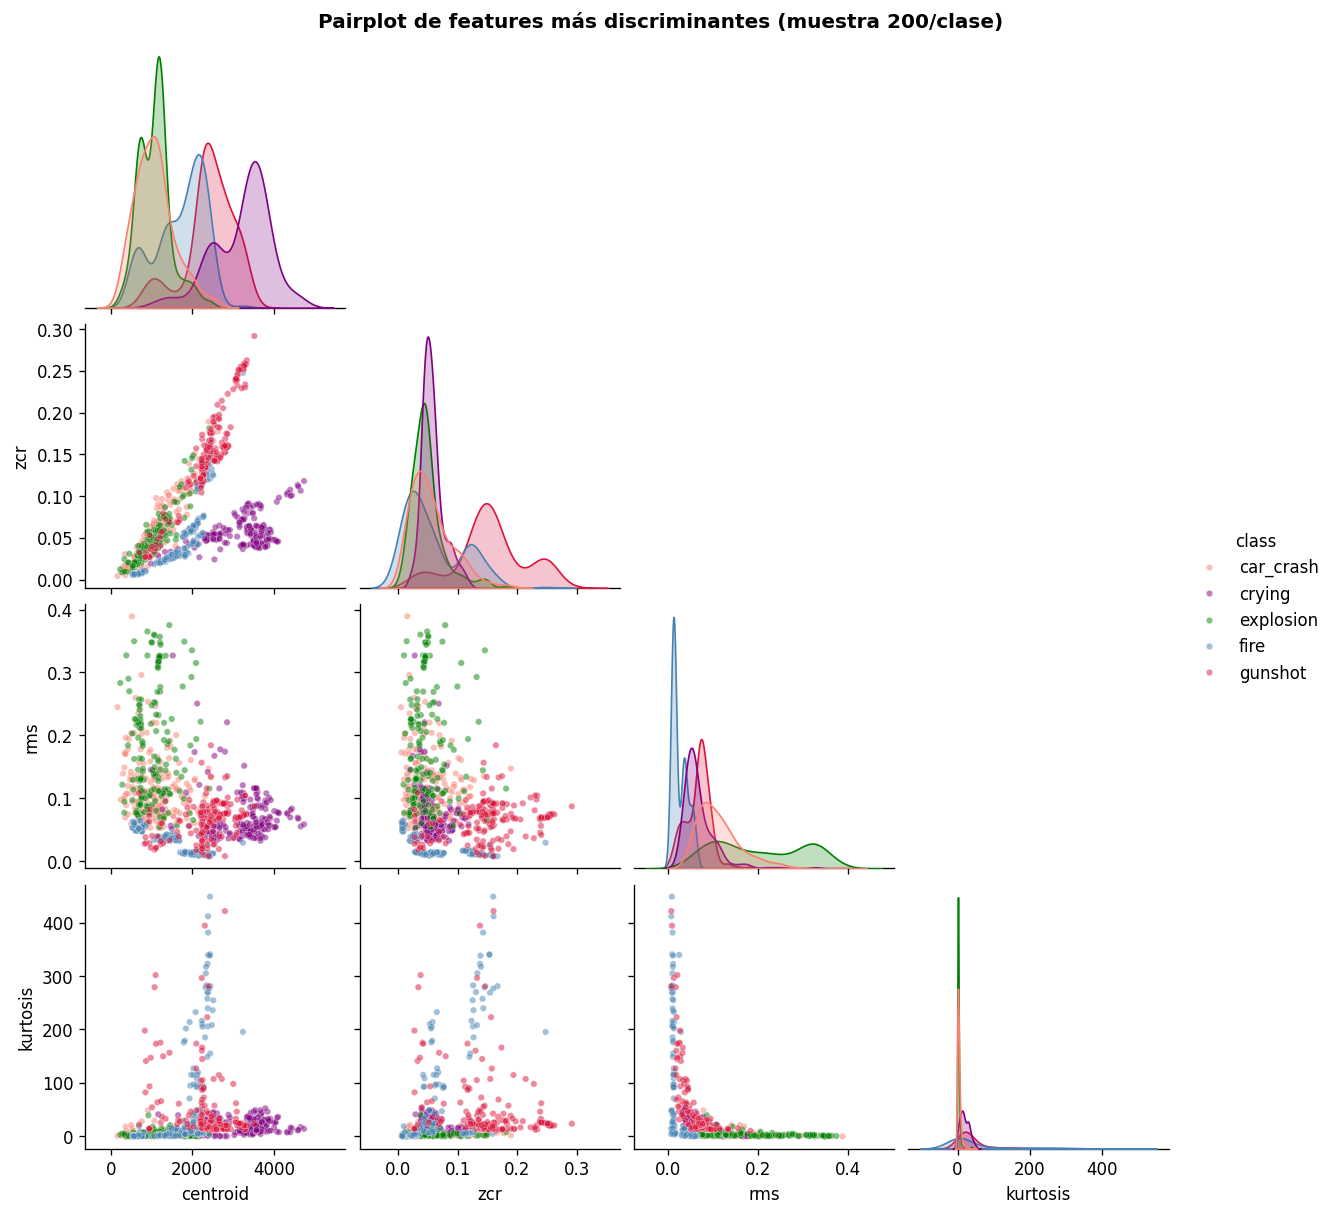

In [24]:
# Usamos un sample para no tardar demasiado
sample = df.groupby('class').apply(
    lambda x: x.sample(min(200, len(x)), random_state=42)
).reset_index(drop=True)

# Solo las features más discriminantes
feats_pair = ['centroid', 'zcr', 'rms', 'kurtosis']
g = sns.pairplot(
    sample[feats_pair + ['class']],
    hue='class',
    palette=COLORS,
    plot_kws=dict(alpha=0.5, s=15),
    diag_kind='kde',
    corner=True
)
g.figure.suptitle('Pairplot de features más discriminantes (muestra 200/clase)', y=1.01, fontweight='bold')
plt.show()

## **10. Conclusiones**

| Feature | Mejor discrimina | Observación |
|---|---|---|
| **centroid** | crying vs resto | crying en ~3.154 Hz, car_crash en ~1.051 Hz. |
| **zcr** | gunshot vs resto | gunshot tiene ZCR medio 0.156 (3 veces más alto que explosion). |
| **rms** | explosion vs fire | explosion tiene 8 veces más energía que fire. |
| **kurtosis** | fire/gunshot vs explosion/car_crash | fire tiene outliers extremos (max 611). |
| **peak** | gunshot vs fire | gunshot tiene un pico medio en 0.83 y fire en 0.43. |
| **attack_ratio** | gunshot vs resto | gunshot está muy disperso (std 10.2). |


### **Recomendaciones para el modelo**
1. **Desbalanceo**: usar `class_weight='balanced'` o SMOTE | ratio gunshot:fire = 1:11.
2. **Outliers en kurtosis y attack_ratio**: considerar clipear al percentil 99 o usar RobustScaler.
3. **explosion**: aclarar si se usan solo los 120 positivos o las 1.705 muestras totales.
4. **Redundancia**: centroid y zcr se correlacionan con un 0.48. Hay que evaluar si eliminar una con PCA.
5. **crying** debería ser la clase más fácil de clasificar por su centroide tan alto.